# (31) dists evo across time

project = ```iP-VAE```, host = ```mach```, device = ```cuda:2```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## vH16

In [3]:
keys = ['poisson', '<grad|lin>', '-vH16', 't-16', 'b-24']

chkpts_dir = add_home('Dropbox/chkpts/_IterativeVAE')
fits = sorted(os.listdir(chkpts_dir), key=alphanum_sort_key)
fits = [
    f for f in fits if
    all(e in f for e in keys)
]
print(fits)

['poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38)']

In [4]:
tr = load_model_lite(pjoin(chkpts_dir, fits[0]), device)[0]

In [6]:
results = tr.xtract_ftr(data_batch_sz=2000, n_data_batches=-1)

100%|█████████████████████████████████| 13/13 [00:36<00:00,  2.77s/it]


In [9]:
os.listdir()

[]

In [13]:
save_obj(
    obj=results,
    file_name=f"xtract_{fits[0]}.npy",
    save_dir='/mnt/sata/hadi',
)

[PROGRESS] 'xtract_poisson-<grad|lin>-vH16-t-16_b-24_mach-1_(2025_03_07,07:38).npy' saved at
/mnt/sata/hadi

In [12]:
list(results)

['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [15]:
results['samples'][:, -1, :]

array([[ 0.,  0.,  4., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0., 23.,  0.],
       [ 0., 12.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  8.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  1.,  0.,  0.],
       [ 0.,  1.,  1., ...,  0.,  0.,  2.]], dtype=float32)

100%|███████████████████████████████████| 2/2 [01:48<00:00, 54.07s/it]


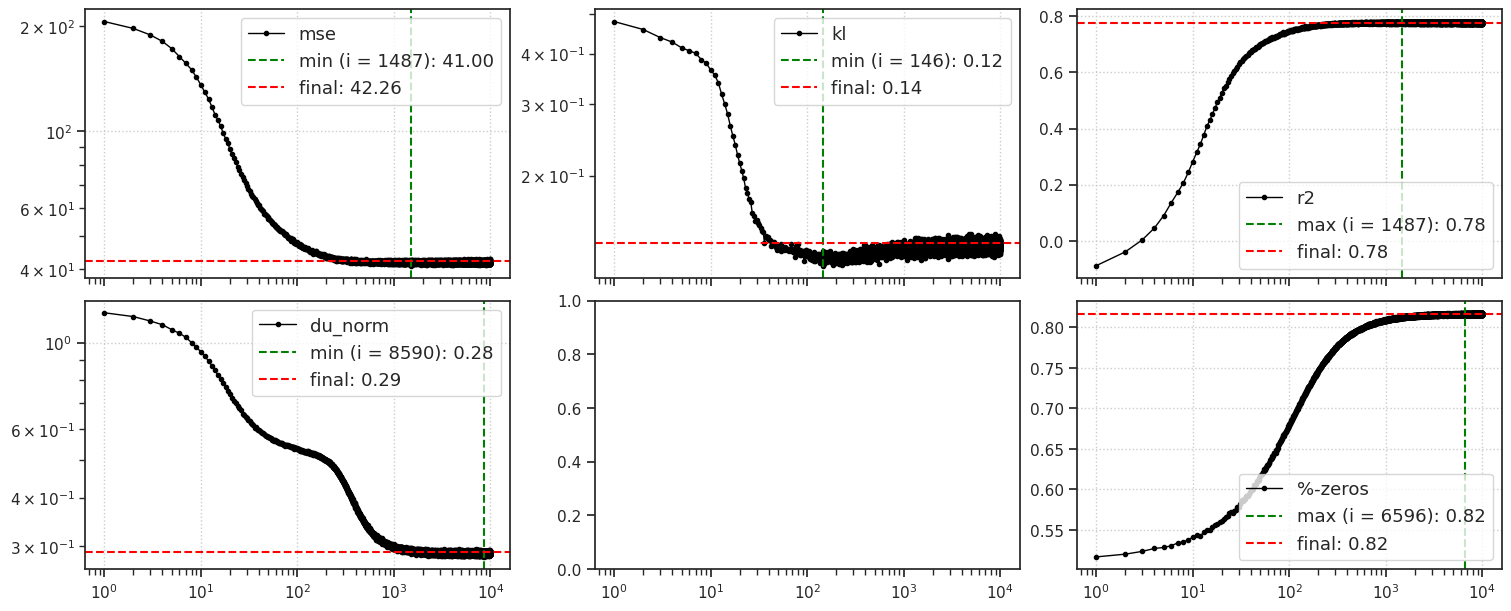

CPU times: user 1min 20s, sys: 8.73 s, total: 1min 29s
Wall time: 2min 9s


In [5]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [6]:
%%time

output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=['x', 'conditional'],
).stack()

CPU times: user 2.41 s, sys: 19.1 ms, total: 2.43 s
Wall time: 2.43 s


In [7]:
list(output)

['loss_kl', 'loss_recon', 'posterior', 'conditional', 'x']

torch.Size([1, 256])

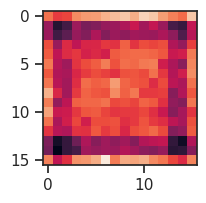

In [9]:
dec_log_sigma = tr.model.layer.get_dec_log_sigma()
dec_var = torch.exp(2.0 * dec_log_sigma)
imshow(dec_var.squeeze().reshape(16, 16))

dec_var.shape

In [10]:
dec_var.min()

tensor(0.4205, device='cuda:2', grad_fn=<MinBackward1>)

In [11]:
pred = torch.stack([
    d.loc for d in
    output['conditional'].values()
], dim=1)

res = output['x'] - pred
res = tonp(res / dec_var)
res.shape

(200, 1000, 256)

<Axes: ylabel='Count'>

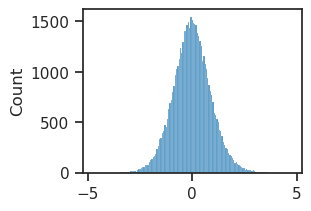

In [15]:
fig, ax = create_figure()
sns.histplot(res[:, -1, :].ravel(), ax=ax)

<Axes: ylabel='Count'>

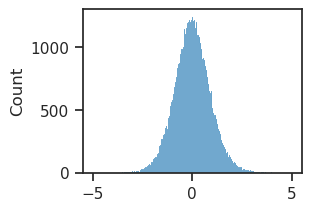

In [17]:
fig, ax = create_figure()
sns.histplot(res[:, -1, :].ravel(), bins = np.linspace(-5, 5, 200), ax=ax)

In [19]:
data = res[:, -1, :].ravel()
mu = data.mean()
sd = data.std()

xs = np.linspace(mu - 4*sd, mu + 4*sd, 500)
pdf = sp_stats.norm.pdf(xs, mu, sd)

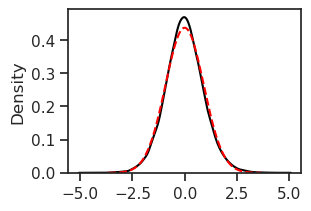

In [26]:
fig, ax = create_figure()
sns.kdeplot(data, color='k', ax=ax)
ax.plot(xs, pdf, color='r', ls='--')

In [5]:
results = tr.xtract_ftr(
    seq_total=100,
    seq_batch_sz=2,
    data_batch_sz=2000,
    n_data_batches=-1,
)

100%|███████████████████████████████████| 5/5 [00:04<00:00,  1.22it/s]


In [30]:
list(results)

['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [31]:
u_final = results['state'][:, -1, :]
r_final = np.exp(u_final)

r_final.shape

(4000, 512)

In [34]:
uu, ss, vh = sp_lin.svd(r_final, full_matrices=False)

In [35]:
ss.shape

(512,)

In [36]:
ss /= sum(ss)

Text(0, 0.5, 'cumulative var\nexplained')

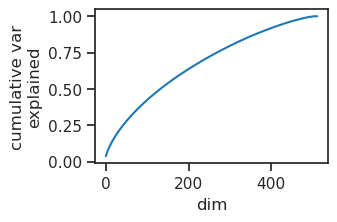

In [68]:
plot(np.cumsum(ss))
plt.xlabel('dim')
plt.ylabel('cumulative var\nexplained')

In [40]:
vh.shape

(512, 512)

In [47]:
from sklearn.decomposition import PCA

In [53]:
pca = PCA(n_components=10).fit(r_final)
r_proj = pca.transform(r_final)

100%|███████████████████████████████████| 5/5 [01:30<00:00, 18.11s/it]


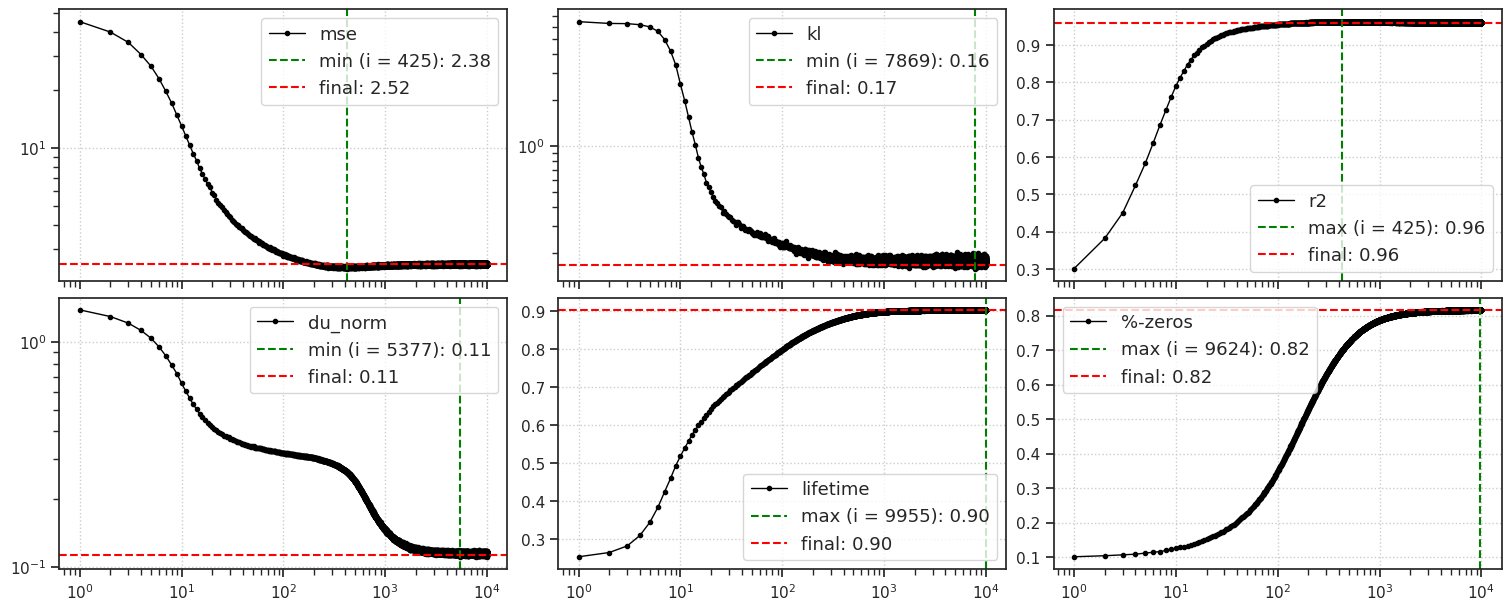

CPU times: user 1min 40s, sys: 3.14 s, total: 1min 43s
Wall time: 1min 44s


In [5]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=5,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [6]:
from analysis.linear import clf_score

In [7]:
results = clf_score(tr, 1000, 100, 5000)

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.32s/it]


In [8]:
print(results['clf_accuracy'])

{
    'trn': {
        1: 0.8620166666666667,
        100: 0.9851333333333333,
        200: 0.9846833333333334,
        300: 0.9840666666666666,
        400: 0.98445,
        500: 0.9844166666666667,
        600: 0.9841666666666666,
        700: 0.98435,
        800: 0.9845,
        900: 0.9841333333333333,
        1000: 0.9843
    },
    'vld': {
        1: 0.868,
        100: 0.9625,
        200: 0.961,
        300: 0.9597,
        400: 0.9604,
        500: 0.9602,
        600: 0.9616,
        700: 0.9601,
        800: 0.9594,
        900: 0.9598,
        1000: 0.9605
    }
}

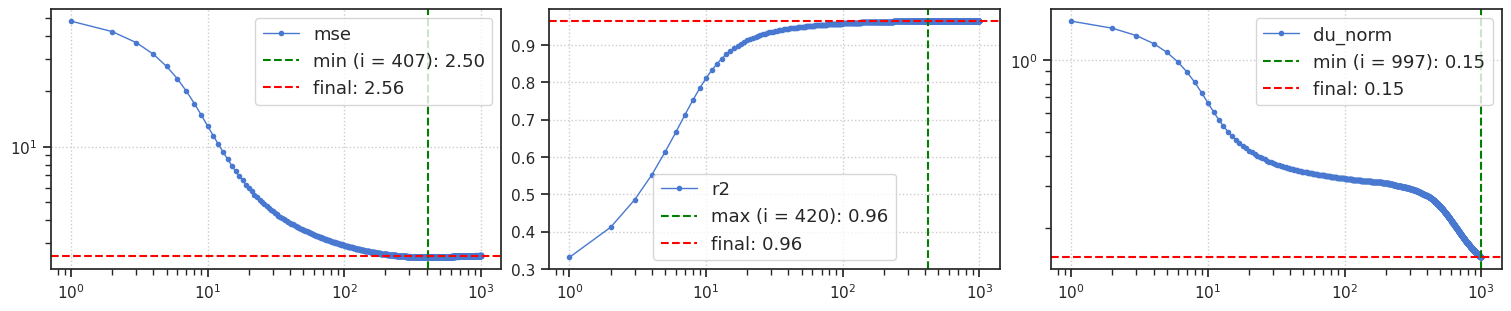

In [14]:
to_plot = results['results_xtract']['vld']

nrows = 1
items = ['mse', 'r2', 'du_norm']
pal_models = get_palette_models()
color = pal_models[tr.model.cfg.model_str]
_ = plot_convergence(
    results=to_plot,
    nrows=nrows,
    items=items,
    color=color,
)

In [15]:
list(to_plot)

['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

## Load & Eval

```(128, 72.0)```

In [3]:
a = 'poisson_MNIST_t-128_z-[512]_u-10,du-10_<grad|lin>'
b = 'b100-ep400-lr(0.002)_beta(72:0.1)_temp(0.01:0.5)_gr(2000)_(2025_03_14,09:22)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

280

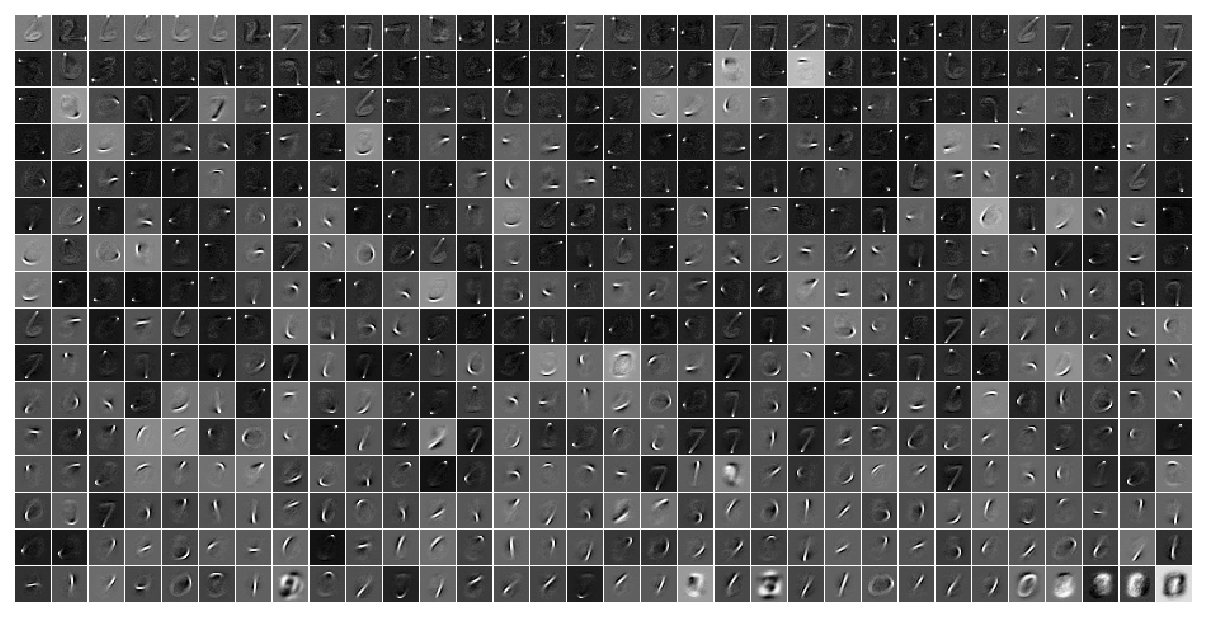

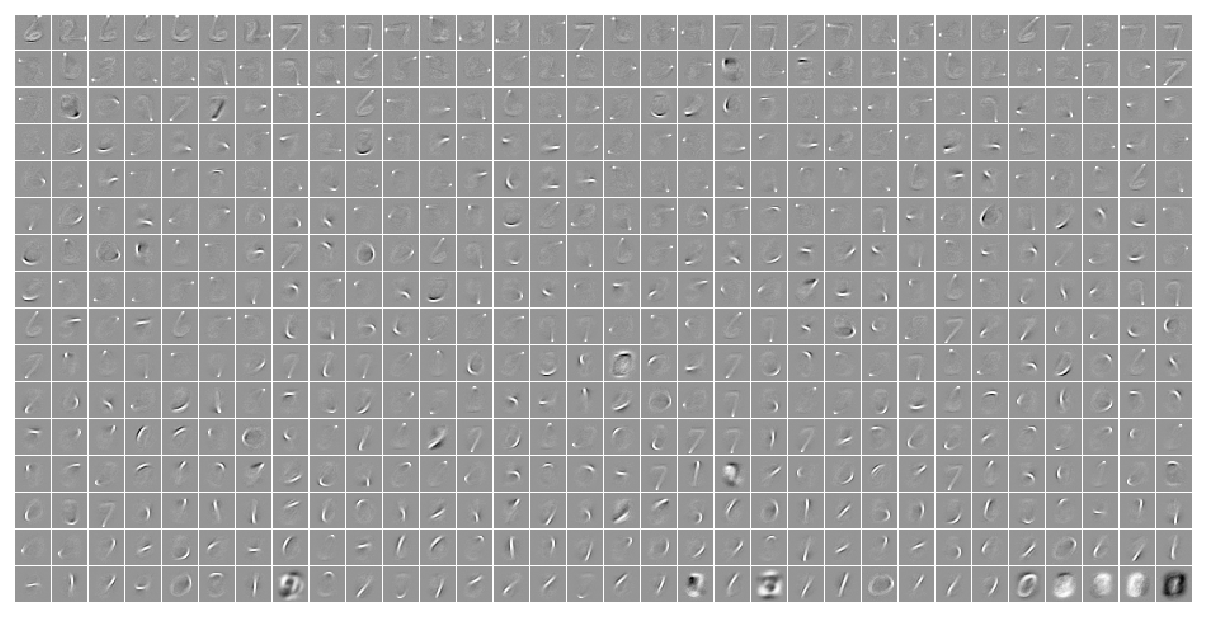

In [4]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 3/3 [00:54<00:00, 18.24s/it]


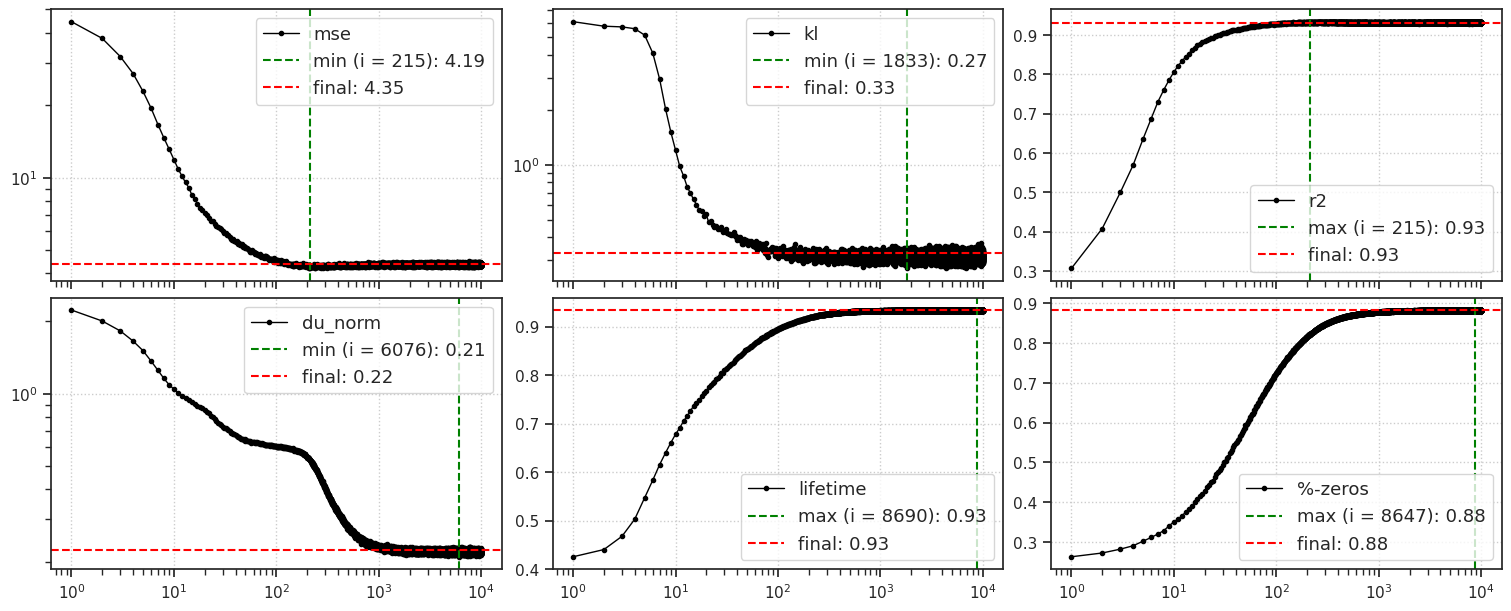

CPU times: user 1min 3s, sys: 2.16 s, total: 1min 5s
Wall time: 1min 5s


In [5]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=3,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [6]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.22s/it]


In [7]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [9]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [10]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.9629

In [11]:
true = tonp(tr.dl_vld.dataset.tensors[1])

accu = {}
for c in [1e-2, 1e-1, 1, 1e2, 1e5, 1e7, 1e10]:
    clf = LogisticRegression(C=c).fit(
        lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))
    pred = clf.predict(lamb['vld'])
    report = classification_report(true, pred, output_dict=True)
    accu[c] = report['accuracy']

In [12]:
print(accu)

{0.01: 0.9628, 0.1: 0.9626, 1: 0.9629, 100.0: 0.9627, 100000.0: 0.9627, 10000000.0: 0.9627, 10000000000.0: 0.9627}

## Load & Eval

```(128, 64.0)```

In [4]:
a = 'poisson_MNIST_t-128_z-[512]_u-10,du-10_<grad|lin>'
b = 'b100-ep400-lr(0.002)_beta(64:0.1)_temp(0.01:0.5)_gr(1000)_(2025_03_13,09:30)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

380

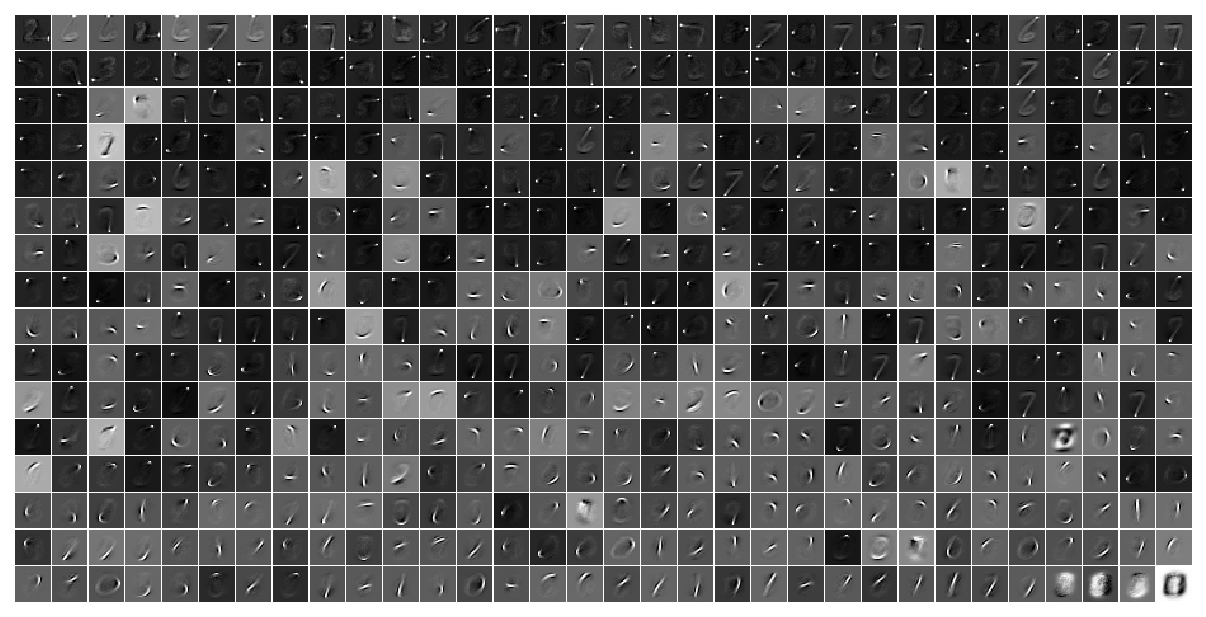

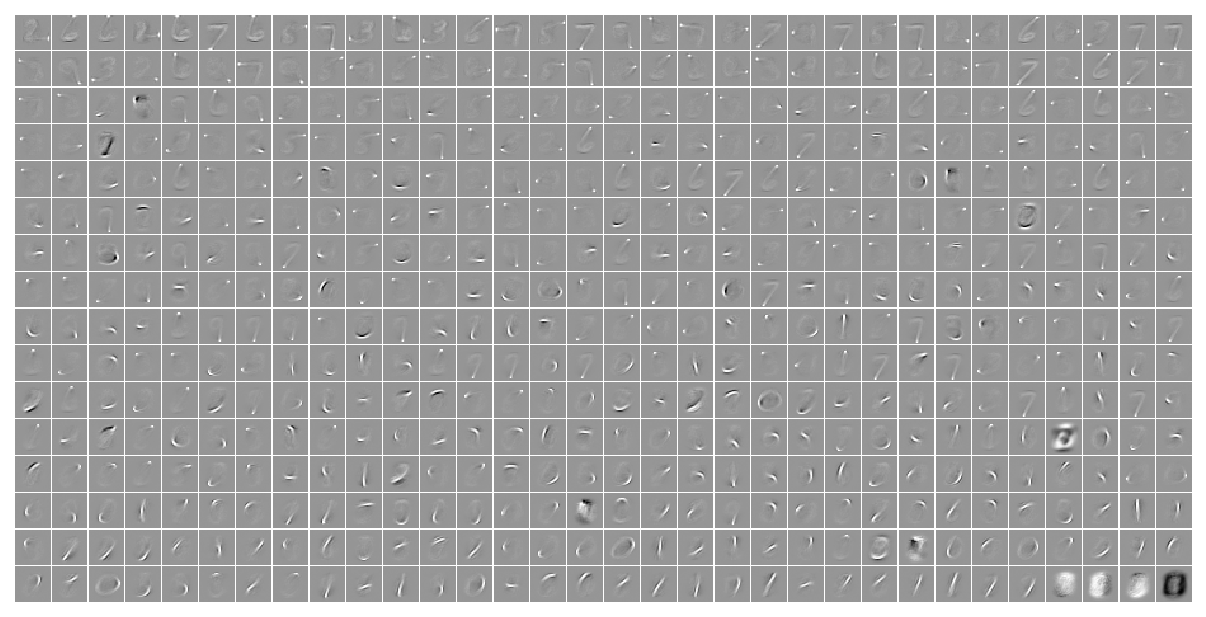

In [5]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:36<00:00, 18.36s/it]


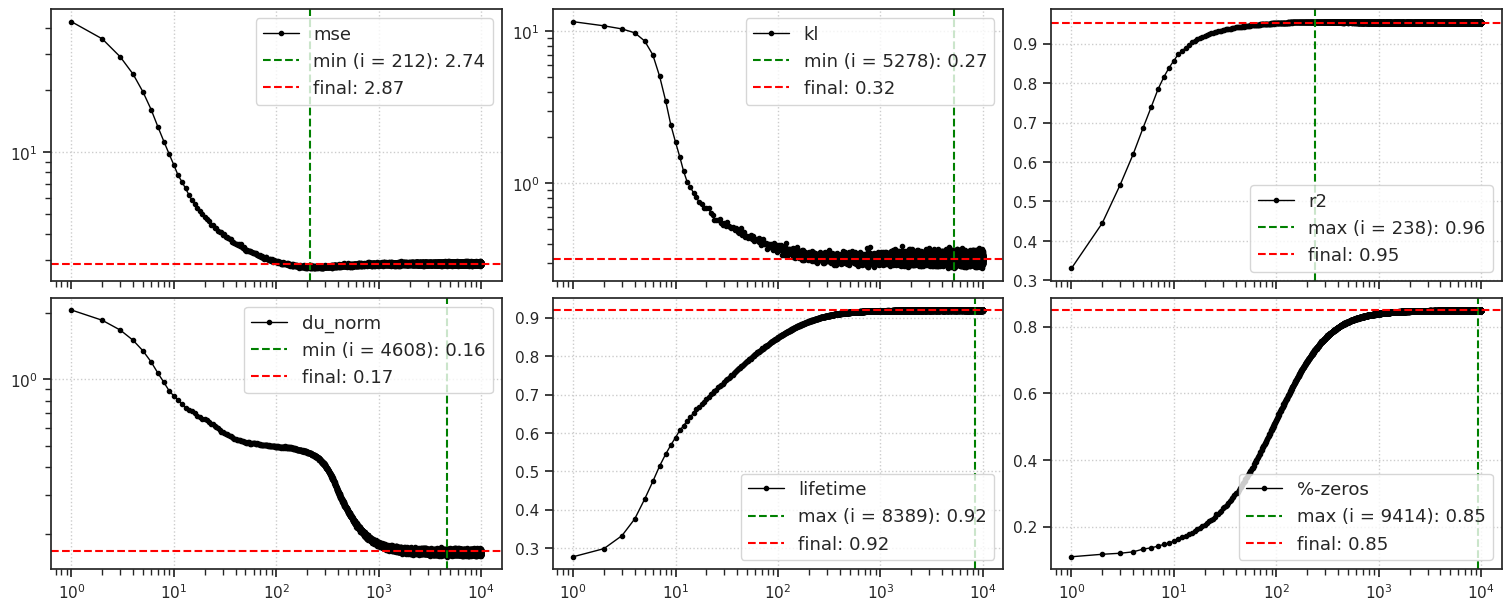

CPU times: user 42.9 s, sys: 1.66 s, total: 44.5 s
Wall time: 44.5 s


In [6]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [7]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.39s/it]


In [8]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [10]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [11]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.9645